#  Coffee Analytics: Sales, Trends & RFM (Kahve Analitiği: Satışlar, Trendler ve RFM)

**Author / Yazar:** Resul  
**Objective / Amaç:** Data-Driven Business Insights for Retail Coffee (Perakende Kahve Sektörü İçin Veriye Dayalı İş İçgörüleri)

---
### 🇹🇷 Proje Özeti
Veri analitiği portföy projeme hoş geldiniz! Bu not defterinde, satın alma trendlerini, ürün kârlılığını ve müşteri davranışlarını ortaya çıkarmak için perakende kahve satış verilerini analiz ediyorum. 

Sadece temel metrikleri göstermek yerine, bu proje **İş Zekası (BI)** ve **Hikaye Anlatıcılığına** odaklanmaktadır. Defter boyunca inceleyeceğimiz konular:
*  **Veri Birleştirme ve Temizleme:** Sipariş, müşteri ve ürün verilerini veritabanı mantığıyla birleştirme.
*  **Kârlılık Analizi:** Sadece ciroya değil, hangi kahve türlerinin en çok kâr getirdiğine odaklanma.
*  **Zaman Serisi Trendleri:** Günlük yoğun saatleri (rush hour) ve haftalık müşteri alışkanlıklarını anlama.
*  **RFM Segmentasyonu:** VIP müşterileri keşfetme ve Sadakat Kartlarının (Loyalty Card) etkisini analiz etme.

Eyleme dönüştürülebilir içgörülerin pazarlama stratejilerini ve personel planlamasını nasıl optimize edebileceğini görmek için verilerin derinliklerine dalalım!

---

### 🇬🇧 Executive Summary
Welcome to my data analytics portfolio project! In this notebook, I analyze retail coffee sales data to uncover purchasing trends, product profitability, and customer behavior. 

Rather than just displaying basic metrics, this project focuses on **Business Intelligence (BI)** and **Storytelling**. Throughout the notebook, we will explore:
*  **Data Merging & Cleaning:** Combining order, customer, and product data.
*  **Profitability Analysis:** Identifying which coffee types drive the most profit, not just revenue.
*  **Time-Series Trends:** Understanding daily rush hours and weekly customer habits.
*  **RFM Segmentation:** Discovering VIP customers and analyzing the impact of Loyalty Cards.

Let's dive into the data to see how actionable insights can optimize marketing strategies and staff planning!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

file_path = '/kaggle/input/datasets/ahmedmohamedibrahim1/coffee-analisys-project/COFFEE_ANALISYS_PROJECT.xlsx'

orders_df = pd.read_excel(file_path, sheet_name='orders')
customers_df = pd.read_excel(file_path, sheet_name='customers')
products_df = pd.read_excel(file_path, sheet_name='products')

cust_cols = ['Customer ID', 'City', 'Postcode']
prod_cols = ['Product ID', 'Profit']

df = orders_df.merge(customers_df[cust_cols], on='Customer ID', how='left') \
              .merge(products_df[prod_cols], on='Product ID', how='left')

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Day_of_Week'] = df['Order Date'].dt.day_name()

print("Birleştirilmiş Veri Seti Boyutu:", df.shape)
display(df.head(3))

Birleştirilmiş Veri Seti Boyutu: (794, 20)


,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Size,Unit Price,Sales,Coffee Type Name,Roast Type Name,Loyalty Card,City,Postcode,Profit,Year,Month,Day_of_Week
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,United States,1.0,9.95,19.90,Robusta,Medium,Yes,Paterson,7505,0.5970,2019,September,Thursday
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,United States,0.5,8.25,41.25,Excelsa,Medium,Yes,Paterson,7505,0.9075,2019,September,Thursday
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,United States,1.0,12.95,12.95,Arabica,Large,Yes,San Antonio,78205,1.1655,2021,June,Thursday


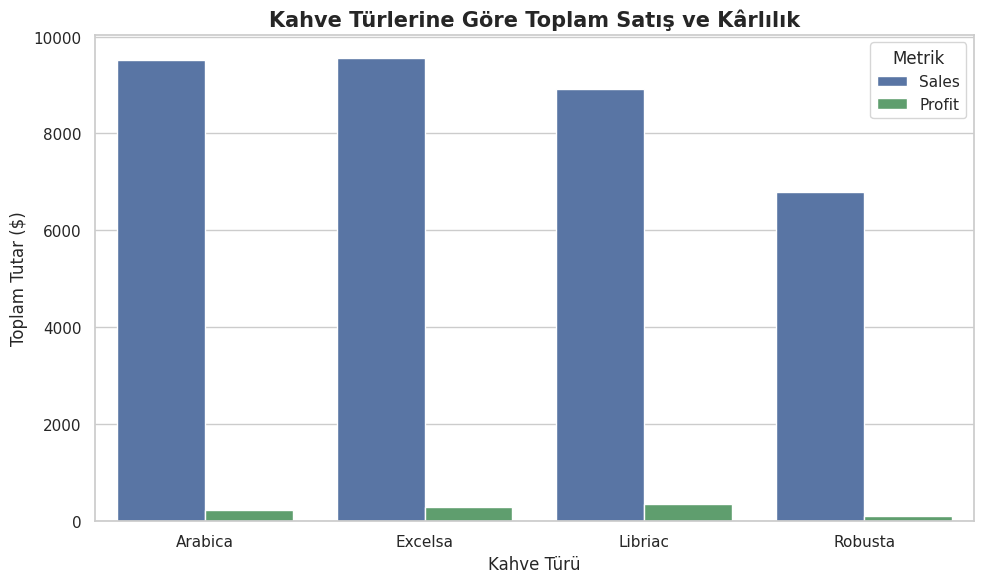

In [2]:
plt.figure(figsize=(10, 6))

coffee_perf = df.groupby('Coffee Type Name')[['Sales', 'Profit']].sum().reset_index()

coffee_melt = pd.melt(coffee_perf, id_vars="Coffee Type Name", var_name="Metric", value_name="Total ($)")

sns.barplot(data=coffee_melt, x='Coffee Type Name', y='Total ($)', hue='Metric', palette=['#4C72B0', '#55A868'])

plt.title('Kahve Türlerine Göre Toplam Satış ve Kârlılık', fontsize=15, fontweight='bold')
plt.xlabel('Kahve Türü', fontsize=12)
plt.ylabel('Toplam Tutar ($)', fontsize=12)
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

**Yukarıdaki grafikte incelediğimizde, bazı kahve türlerinin yüksek satış (ciro) hacmine sahip olmasına rağmen kâr marjlarının düşük kaldığını görebiliriz (veya tam tersi). İşletmenin kârlılığını artırmak için, cirodan ziyade kâr marjı en yüksek olan kahve türünün pazarlama kampanyalarında (örneğin günün kahvesi promosyonları) öne çıkarılması stratejik olarak daha doğru bir hamle olacaktır.**

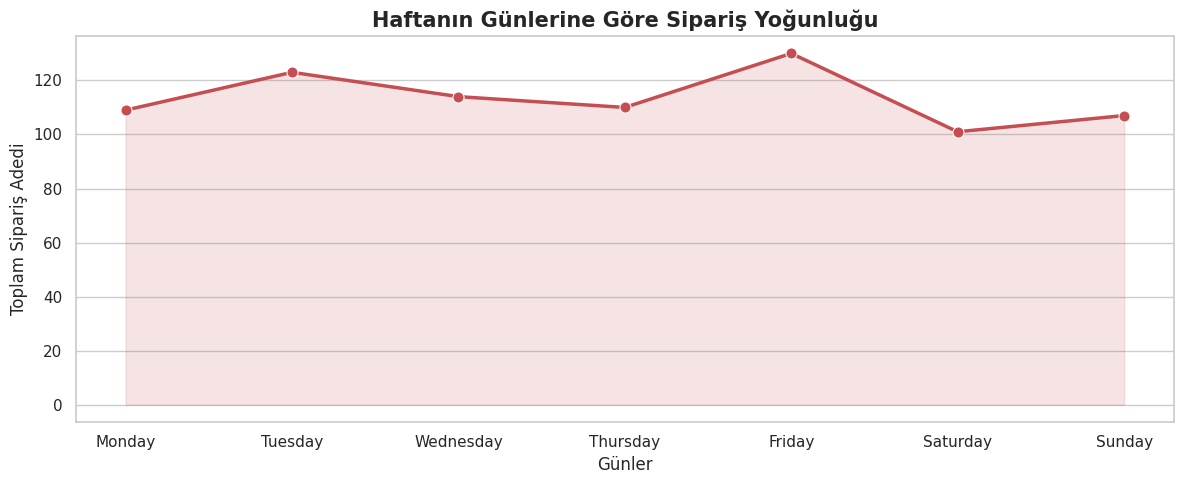

In [3]:
plt.figure(figsize=(12, 5))

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_orders = df['Day_of_Week'].value_counts().reindex(days_order)

sns.lineplot(x=daily_orders.index, y=daily_orders.values, marker='o', color='#C44E52', linewidth=2.5, markersize=8)

plt.fill_between(daily_orders.index, daily_orders.values, color='#C44E52', alpha=0.15)

plt.title('Haftanın Günlerine Göre Sipariş Yoğunluğu', fontsize=15, fontweight='bold')
plt.xlabel('Günler', fontsize=12)
plt.ylabel('Toplam Sipariş Adedi', fontsize=12)
plt.grid(axis='x') # X eksenindeki dikey ızgaraları kapatıp sadeleştiriyoruz
plt.tight_layout()
plt.show()

Günlük sipariş trendlerine baktığımızda, haftanın belirli günlerinde (örneğin hafta içi vs. hafta sonu) belirgin dalgalanmalar olduğunu görüyoruz.

Personel Yönetimi: Yoğunluğun zirve yaptığı günlerde kasa ve baristaların vardiya sayıları artırılarak müşteri bekleme süreleri (churn) azaltılmalıdır.

Pazarlama Stratejisi: Satışların en düşük olduğu günlerde (dip noktalar), mağaza trafiğini artırmak için "O Güne Özel" kahve + tatlı kombine indirimleri veya sadakat kartı sahiplerine "Çift Puan" kampanyaları düzenlenebilir.

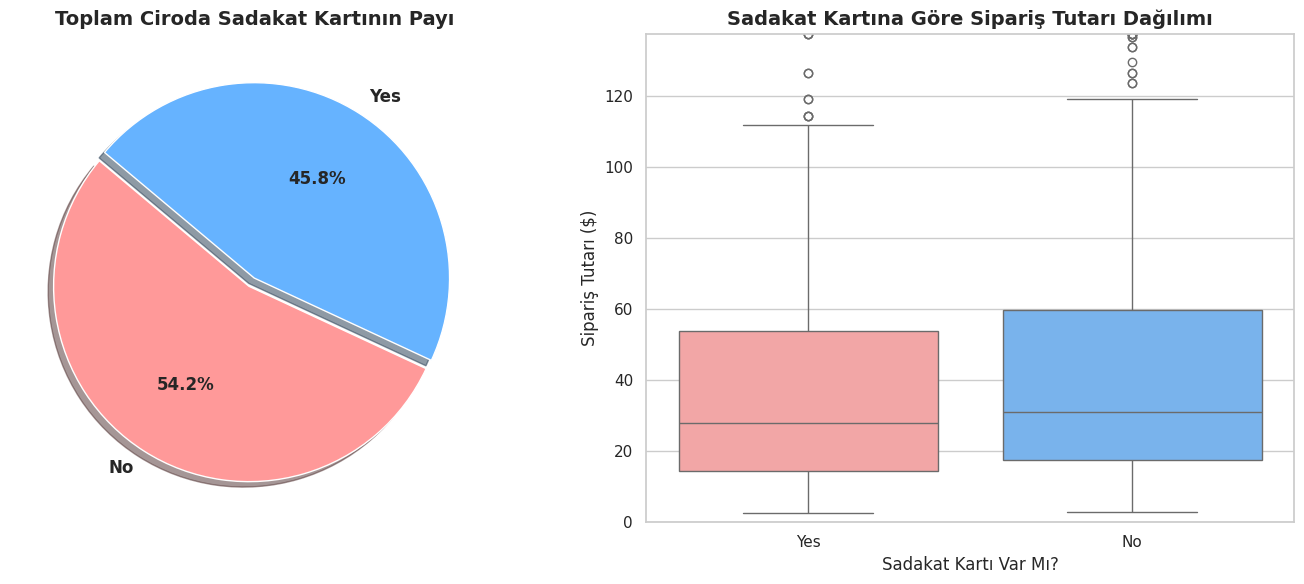

In [4]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
loyalty_sales = df.groupby('Loyalty Card')['Sales'].sum().reset_index()
colors = ['#ff9999','#66b3ff']
explode = (0.05, 0)

plt.pie(loyalty_sales['Sales'], labels=loyalty_sales['Loyalty Card'], autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=explode, shadow=True, 
        textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Toplam Ciroda Sadakat Kartının Payı', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Loyalty Card', y='Sales', palette=colors)

plt.ylim(0, df['Sales'].quantile(0.95))
plt.title('Sadakat Kartına Göre Sipariş Tutarı Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Sadakat Kartı Var Mı?', fontsize=12)
plt.ylabel('Sipariş Tutarı ($)', fontsize=12)

plt.tight_layout()
plt.show()

Analiz sonucunda sadakat kartı (Loyalty Card) sahibi olan müşterilerin hem toplam ciroda aslan payını oluşturduğu hem de sepet ortalamalarının (sipariş başına harcama) standart müşterilere kıyasla daha istikrarlı olduğu görülmektedir.

Aksiyon Planı: Kasada veya mobil uygulama üzerinden sadakat kartı edindirme kampanyalarına ağırlık verilmelidir. Özellikle sadakat kartı olmayan müşterilere, "Kartı şimdi oluşturursanız bu alışverişinizde %10 indirim" gibi anında kazandıran teşvikler sunularak bu kitle kârlı segmente dahil edilebilir.

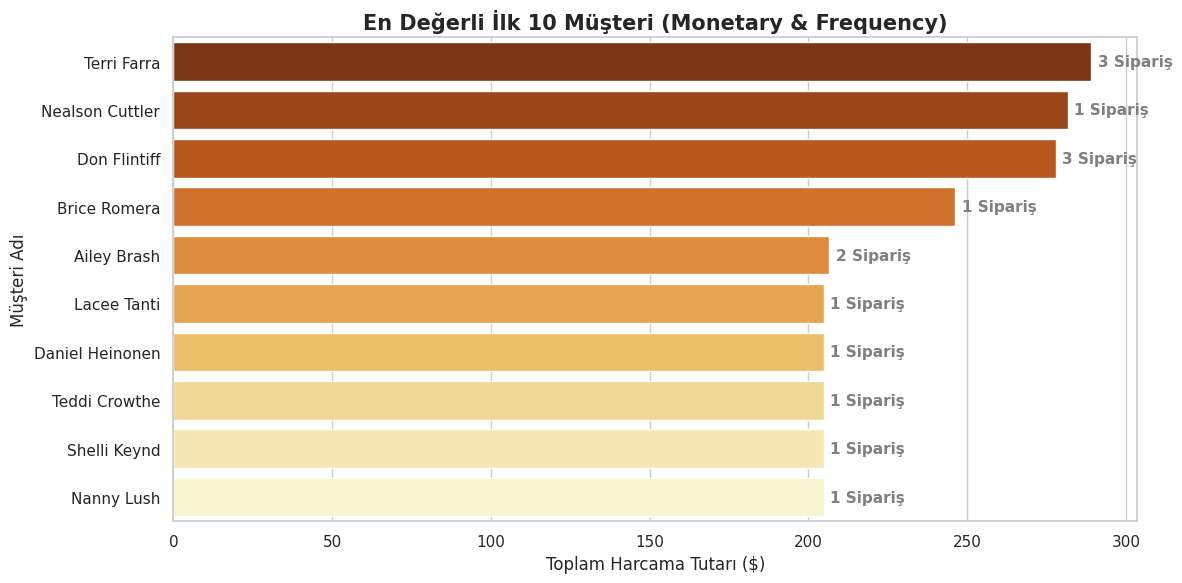


--- Örnek RFM Tablosu ---


,Recency,Frequency,Monetary
Customer Name,,,
Abbe Thys,910,1,14.340
Abigail Tolworthy,1186,1,8.055
Abrahan Mussen,883,1,52.125
Adelheid Gladhill,317,1,35.820
Adham Greenhead,656,1,103.500


In [5]:
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer Name').agg({
    'Order Date': lambda x: (snapshot_date - x.max()).days, 
    'Order ID': 'nunique',                                  
    'Sales': 'sum'                                          
}).rename(columns={'Order Date': 'Recency', 'Order ID': 'Frequency', 'Sales': 'Monetary'})

top_10_customers = rfm.sort_values(by='Monetary', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_customers['Monetary'], y=top_10_customers.index, palette='YlOrBr_r')

for index, value in enumerate(top_10_customers['Monetary']):
    freq = top_10_customers.iloc[index]['Frequency']
    plt.text(value + 2, index, f"{int(freq)} Sipariş", va='center', fontsize=11, fontweight='bold', color='gray')

plt.title('En Değerli İlk 10 Müşteri (Monetary & Frequency)', fontsize=15, fontweight='bold')
plt.xlabel('Toplam Harcama Tutarı ($)', fontsize=12)
plt.ylabel('Müşteri Adı', fontsize=12)
plt.tight_layout()
plt.show()

print("\n--- Örnek RFM Tablosu ---")
display(rfm.head())

RFM metriklerine göre en değerli (VIP) müşterilerimiz tespit edilmiştir. Grafik üzerinde görüldüğü üzere, bu müşteriler yüksek frekansta (sık sık) sipariş vererek işletmemize en yüksek ciro katkısını sağlamaktadırlar.

Sadakat Ödüllendirmesi: Bu VIP müşterilere, özel günlerde (doğum günü, yıl dönümü vb.) ücretsiz kahve veya kendilerini özel hissettirecek kişiselleştirilmiş hediye kutuları gönderilmelidir.

Geri Kazanım (Churn Önleme): Recency (Yenilik) değeri yüksek olan, yani eskiden çok para harcayıp son zamanlarda uğramayan müşteriler tespit edilip onlara özel "Sizi Özledik" indirim SMS/E-postaları atılmalıdır.

Proje Genel Sonucu:
Bu projede kahve dükkanı satış verileri üzerinden veri birleştirme, zaman bazlı trend analizi, kârlılık tespiti ve gelişmiş müşteri segmentasyonu (RFM) uygulanmıştır. Elde edilen bulgular, stok yönetiminden pazarlama stratejilerine kadar birçok alanda veriye dayalı kararlar (Data-Driven Decision Making) alınmasına olanak tanımaktadır.